# VGG-16

In [1]:
import os
import time
import random
import urllib.request
import tarfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
DATA_DIR = "../data"
IMAGENETTE_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2.tgz"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

if not os.path.exists(IMAGENETTE_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    tgz_path = os.path.join(DATA_DIR, "imagenette2.tgz")
    print("Downloading Imagenette...")
    urllib.request.urlretrieve(IMAGENETTE_URL, tgz_path)
    print("Extracting...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        tar.extractall(DATA_DIR)
    os.remove(tgz_path)
    print("Done.")
else:
    print("Imagenette already downloaded.")

Imagenette already downloaded.


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [32, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [5]:
class VGG16(nn.Module):

    cfg = [64, 64, 'M',
           128, 128, 'M',
           256, 256, 256, 'M',
           512, 512, 512, 'M',
           512, 512, 512, 'M']

    def __init__(self, num_classes=10):
        super().__init__()
        self.features = self._make_layers(self.cfg)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for v in cfg:
            if v == 'M':
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                layers.append(nn.Conv2d(in_channels, v, kernel_size=3, padding=1))
                layers.append(nn.ReLU(inplace=True))
                in_channels = v
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)

model = VGG16(num_classes=10).to(device)
print(model)

VGG16(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation

In [ ]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [64, 10]

Output shape: torch.Size([64, 10])


In [ ]:
def count_conv_params(in_ch, out_ch, kernel_size=3):
    return (kernel_size * kernel_size * in_ch + 1) * out_ch

def count_fc_params(in_features, out_features):
    return (in_features + 1) * out_features

conv_channels = [
    (3, 64), (64, 64),
    (64, 128), (128, 128),
    (128, 256), (256, 256), (256, 256),
    (256, 512), (512, 512), (512, 512),
    (512, 512), (512, 512), (512, 512),
]

conv_total = sum(count_conv_params(i, o) for i, o in conv_channels)
fc6 = count_fc_params(512 * 7 * 7, 4096)
fc7 = count_fc_params(4096, 4096)
fc8 = count_fc_params(4096, 10)

manual_total = conv_total + fc6 + fc7 + fc8
torch_total = sum(p.numel() for p in model.parameters())

print(f"Conv layers total: {conv_total:,}")
print(f"FC6: {fc6:,}")
print(f"FC7: {fc7:,}")
print(f"FC8: {fc8:,}")
print(f"Manual total: {manual_total:,}")
print(f"torch total:  {torch_total:,}")
assert manual_total == torch_total, "Mismatch between manual and torch parameter count"

Conv layers total: 14,714,688
FC6: 102,764,544
FC7: 16,781,312
FC8: 40,970
Manual total: 134,301,514
torch total:  134,301,514


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [11]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=2.1817 train_acc=0.1778 | val_loss=2.0674 val_acc=0.2242 | time=252.5s
Epoch 2/10 | train_loss=2.0990 train_acc=0.2196 | val_loss=2.0249 val_acc=0.2703 | time=251.0s
Epoch 3/10 | train_loss=2.0149 train_acc=0.2779 | val_loss=1.8655 val_acc=0.3470 | time=251.1s
Epoch 4/10 | train_loss=1.9124 train_acc=0.3345 | val_loss=1.7582 val_acc=0.4273 | time=251.1s
Epoch 5/10 | train_loss=1.8194 train_acc=0.3700 | val_loss=1.6582 val_acc=0.4196 | time=251.1s
Epoch 6/10 | train_loss=1.6591 train_acc=0.4373 | val_loss=1.4237 val_acc=0.5241 | time=251.2s
Epoch 7/10 | train_loss=1.5518 train_acc=0.4742 | val_loss=1.2722 val_acc=0.5720 | time=251.1s
Epoch 8/10 | train_loss=1.4411 train_acc=0.5206 | val_loss=1.1929 val_acc=0.6125 | time=251.4s
Epoch 9/10 | train_loss=1.3698 train_acc=0.5432 | val_loss=1.1217 val_acc=0.6301 | time=251.3s
Epoch 10/10 | train_loss=1.2991 train_acc=0.5656 | val_loss=1.0391 val_acc=0.6617 | time=251.3s


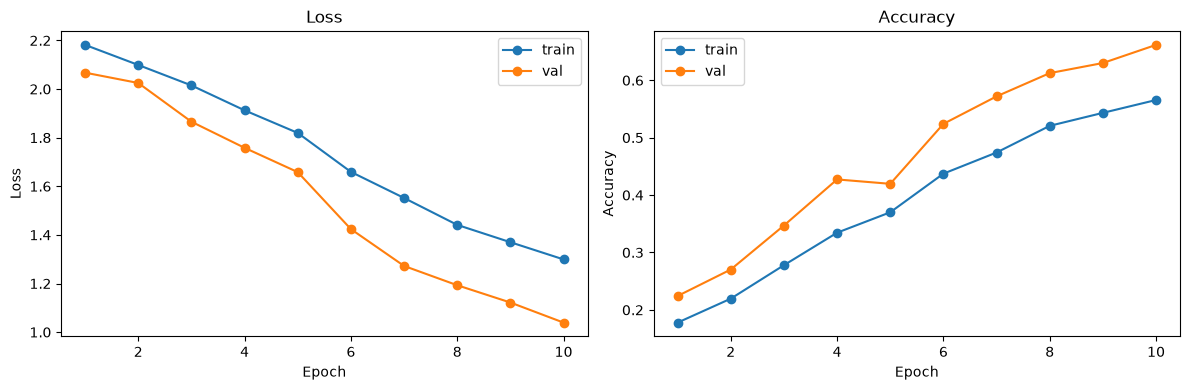

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

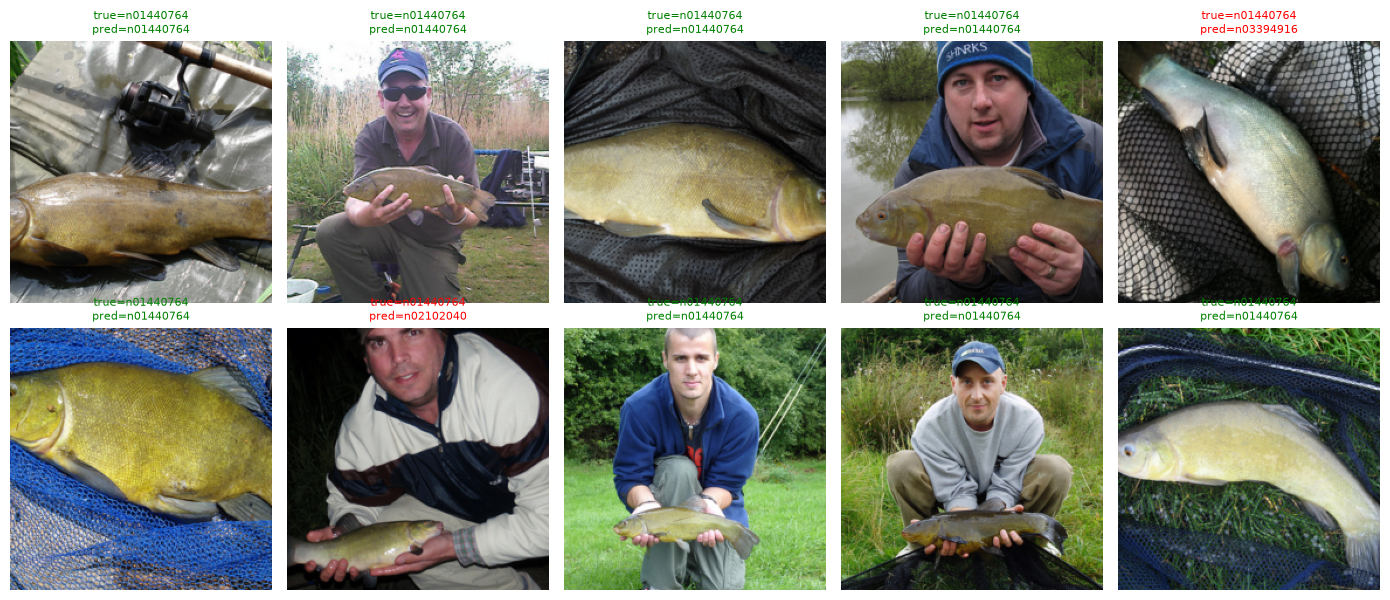

In [13]:
model.eval()
sample_images, sample_labels = next(iter(val_loader))
class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: see manual vs. torch count
above (matches exactly). As with AlexNet, the fully connected layers
(FC6/FC7/FC8) dominate the parameter count — FC6 alone (input 512x7x7=25088)
accounts for the large majority of the ~134M total, even though the
convolutional part is 13 layers deep.

**Training dynamics — why 1 epoch was not representative.** With a single
epoch, VGG16 barely moved off the ln(10) ≈ 2.303 plateau (train_loss=2.30,
val_acc=0.11 — essentially random). This matches what the original paper
reports: without batch normalization (not yet invented in 2014), a 13-layer
plain conv stack is slow to leave this plateau from random initialization.
The original authors worked around this by pretraining a shallower
configuration (11 layers) and using its weights to initialize the deeper
variants.

We instead simply trained longer (10 epochs) to confirm this was a speed
issue, not a broken training run. Loss dropped steadily from ~2.2 to ~1.3
and val accuracy climbed to ~0.67 with no sign of divergence or plateauing
by epoch 10 — the architecture is learning correctly, it just needs more
iterations to escape the initial plateau than shallower networks like
AlexNet do. We stopped at 10 epochs since the trend was already clear and
further training was not needed to validate the architecture.